## Model and System Properties

In [ ]:
import os
from pathlib import Path

_cwd = Path.cwd().resolve()
if _cwd.name == 'run':
    _run_dir = _cwd
elif _cwd.name in ('SBI', 'HBM'):
    _run_dir = _cwd.parent
elif (_cwd / 'run').exists():
    _run_dir = _cwd / 'run'
else:
    _run_dir = _cwd

_repo_root = _run_dir.parent
_inputs_dir = _repo_root / 'inputs'
os.environ['POSEIDON_input_data'] = str(_inputs_dir)
os.environ['PYSYN_CDBS'] = str(_inputs_dir / 'stellar_grids')

from POSEIDON.constants import R_Sun, R_J, R_E, M_E
from POSEIDON.core import create_star, create_planet, load_data, define_model, \
                          wl_grid_constant_R, set_priors, read_opacities
from POSEIDON.visuals import plot_data, plot_spectra_retrieved, plot_PT_retrieved, \
                             plot_chem_retrieved
from POSEIDON.retrieval import run_retrieval, postprocess_sbi_raw
from POSEIDON.corner import generate_cornerplot
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, \
                             read_retrieved_log_X, plot_collection

import numpy as np
import time
from sbi.analysis import pairplot
import matplotlib.pyplot as plt

from scipy.constants import parsec as pc

do_retrieval = True
# do_retrieval = False
retrieval_algorithm = 'snpe'   # Options: 'MultiNest', 'sbi', 'npe', 'snpe', 'npe_c', 'snpe_c', 'npe_a', 'snpe_a', 'fmpe', 'npse', 'nle', 'snle', 'nle_a', 'snle_a', 'nre', 'snre', 'nre_a', 'snre_a', 'nre_b', 'snre_b', 'nre_c', 'snre_c', or 'bnre'
do_sbi_postprocess_only = True
do_sbi_postprocess_only = False  # True -> reuse SBI_raw samples, skip SBI rounds

#data_included = 'NIRISS'
# data_included = 'NIRISS_WFC3'
#data_included = 'G395H'
data_included = 'NIRISS_G395H_Tiberius'


#model_name = 'joint_flat_CLR_' + data_included
#model_name = 'joint_multigas-H2O_TS_CLR_' + data_included
model_name = retrieval_algorithm.upper() + '_joint_multigas_' + data_included


stellar_contam = None
# stellar_contam = 'one_spot'
#stellar_contam = 'one_spot_free_log_g'
#stellar_contam = 'two_spots'
#stellar_contam = 'two_spots_free_log_g'

#***** Model wavelength grid *****#

wl_min = 0.58      # Minimum wavelength (um)           2.8
wl_max = 5.30      # Maximum wavelength (um)           5.3
R = 20000          # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define stellar properties *****#

R_s = 0.38*R_Sun      # Stellar radius (m)
T_s = 3506.0          # Stellar effective temperature (K)
err_T_s = 70          # Value in ExoMast
Met_s = -0.20         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.872       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, wl = wl)
# star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s, 
#                   stellar_grid = 'phoenix',
#                   interp_backend = 'pymsg',
#                   wl = wl)

#***** Define planet properties *****#

planet_name = 'TOI-270d'  # Planet name used for plots, output files etc.

R_p = 2.133*R_E     # Planetary radius (m)
M_p = 4.78*M_E      # Planet mass
T_eq = 387.8       # Equilibrium temperature (K)
d = 22.453*pc       # Distance to system (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq, d = d)

# SBI training schedule
sbi_round_sizes = (32000, 16000, 16000)

if '__file__' in globals():
    RUN_DIR = Path(__file__).resolve().parents[1]
else:
    _cwd = Path.cwd().resolve()
    if _cwd.name == 'run':
        RUN_DIR = _cwd
    elif _cwd.name in ('SBI', 'HBM'):
        RUN_DIR = _cwd.parent
    elif (_cwd / 'run').exists():
        RUN_DIR = _cwd / 'run'
    else:
        RUN_DIR = _cwd

DATA_ROOT = RUN_DIR / 'data'
OUTPUT_ROOT = RUN_DIR / 'POSEIDON_output'
os.chdir(RUN_DIR)

#***** Specify data location and instruments *****#

data_dir = str(DATA_ROOT / planet_name)

datasets = []
instruments = []

if ('NIRISS' in data_included):

    datasets.append(planet_name + '_NIRISS_SOSS_Ord2_ExoTEP.dat')
    datasets.append(planet_name + '_NIRISS_SOSS_Ord1_ExoTEP.dat')
    instruments.append('JWST_NIRISS_SOSS_Ord2')
    instruments.append('JWST_NIRISS_SOSS_Ord1')

if ('G395H_Eureka-feature' in data_included):

    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_Eureka.dat',)
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_Eureka-CS2.dat')
    instruments.append('JWST_NIRSPec_G395H_NRS1')
    instruments.append('JWST_NIRSPec_G395H_NRS2')
elif ('G395H_Eureka' in data_included):

    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_Eureka.dat',)
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_Eureka.dat')
    instruments.append('JWST_NIRSPec_G395H_NRS1')
    instruments.append('JWST_NIRSPec_G395H_NRS2')
elif ('G395H_Tiberius-feature' in data_included):

    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_Tiberius.dat',)
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_Tiberius-CS2.dat')
    instruments.append('JWST_NIRSPec_G395H_NRS1')
    instruments.append('JWST_NIRSPec_G395H_NRS2')
elif ('G395H_Tiberius' in data_included):

    datasets.append(planet_name + '_NIRSpec_G395H_NRS1_Tiberius.dat',)
    datasets.append(planet_name + '_NIRSpec_G395H_NRS2_Tiberius.dat')
    instruments.append('JWST_NIRSPec_G395H_NRS1')
    instruments.append('JWST_NIRSPec_G395H_NRS2')

data = load_data(data_dir, datasets, instruments, wl)


/home/eraul/miniconda3/envs/.atmos_25/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Atmosphere Properties and Priors

In [2]:
#***** Define model *****#

# Create the model object
if ('multigas' in model_name):

   bulk_species = ['H2', 'He']     # H2 + He comprises the bulk atmosphere

   param_species = ['H2O', 'CH4', 'CO2', 'SO2', 'CO', 'NH3', 'N2', 'CS2']
   
   if ('clear' in model_name):
      surface = False
      cloud_model = 'cloud-free'
      cloud_type = 'deck_haze'
   else:
      surface = False
      cloud_model = 'MacMad17'
      cloud_type = 'deck_haze'

   model = define_model(model_name, bulk_species, param_species, 
                        radius_unit = 'R_E', surface = surface,
                        PT_profile = 'isotherm', cloud_model = cloud_model,
                        cloud_type = cloud_type,
                        stellar_contam = stellar_contam,
                        # offsets_applied = 'single_dataset',
                       )
elif ('minimal' in model_name):

   bulk_species = ['H2', 'He']     # H2 + He comprises the bulk atmosphere

   param_species = ['H2O', 'CH4', 'CO2', 'CS2']
   
   if ('clear' in model_name):
      surface = False
      cloud_model = 'cloud-free'
      cloud_type = 'deck_haze'
   else:
      surface = False
      cloud_model = 'MacMad17'
      cloud_type = 'deck_haze'

   model = define_model(model_name, bulk_species, param_species, 
                        radius_unit = 'R_E', surface = surface,
                        PT_profile = 'isotherm', cloud_model = cloud_model,
                        cloud_type = cloud_type,
                        stellar_contam = stellar_contam,
                        # offsets_applied = 'single_dataset',
                       )
elif ('H2O' in model_name):

   bulk_species = ['H2O']
   param_species = []

   model = define_model(model_name, bulk_species, param_species, 
                        radius_unit = 'R_E', surface = False,
                        PT_profile = 'isotherm', cloud_model = 'MacMad17',
                        cloud_type = 'deck_haze',
                        stellar_contam = stellar_contam,
                        # offsets_applied = 'single_dataset',
                       )
   
elif ('flat' in model_name):

   bulk_species = ['H2', 'He']
   param_species = []

   model = define_model(model_name, bulk_species, param_species, 
                        radius_unit = 'R_E', surface = True,
                        disable_atmosphere = True,
                        stellar_contam = stellar_contam,
                        # offsets_applied = 'single_dataset',
                        )

#***** Set priors for retrieval *****#

# Initialise prior type dictionary
prior_types = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types['R_p_ref'] = 'uniform'
prior_types['T'] = 'uniform'
# prior_types['log_X'] = 'CLR'
prior_types['log_X'] = 'uniform'
prior_types['log_P_surf'] = 'uniform'
prior_types['log_a'] = 'uniform'
prior_types['gamma'] = 'uniform'
prior_types['log_P_cloud'] = 'uniform'
prior_types['f_cloud'] = 'uniform'
prior_types['delta_rel'] = 'uniform'

prior_types['T_het'] = 'uniform'
prior_types['f_het'] = 'uniform'
prior_types['T_phot'] = 'gaussian'

prior_types['log_g_het'] = 'uniform'
prior_types['log_g_phot'] = 'gaussian'

prior_types['f_spot'] = 'uniform'
prior_types['f_fac'] = 'uniform'
prior_types['T_spot'] = 'uniform'
prior_types['T_fac'] = 'uniform'
prior_types['log_g_spot'] = 'uniform'
prior_types['log_g_fac'] = 'uniform'

# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['R_p_ref'] = [0.60*R_p, 1.15*R_p]
prior_ranges['T'] = [100, 1000]
prior_ranges['a1'] = [0.02, 2.0]
prior_ranges['a2'] = [0.02, 2.0]
prior_ranges['log_P1'] = [-7, 2]
prior_ranges['log_P2'] = [-7, 2]
prior_ranges['log_P3'] = [-2, 2]
prior_ranges['T_deep'] = [100, 1000]
prior_ranges['log_X'] = [-12, 0.0]
prior_ranges['log_a'] = [-4, 8]
prior_ranges['gamma'] = [-20, 2]
prior_ranges['log_P_cloud'] = [-7, 2]
prior_ranges['f_cloud'] = [0, 1]
prior_ranges['f_het'] = [0.0, 0.5]
prior_ranges['T_het'] = [2300, 1.2*T_s]
prior_ranges['T_phot'] = [T_s, err_T_s]
# prior_ranges['log_g_het'] = [3.0, 5.4]
# prior_ranges['log_g_phot'] = [log_g_s, err_log_g_s]
# prior_ranges['delta_rel'] = [-500, +500]

prior_ranges['f_spot'] = [0.0, 0.5]
prior_ranges['f_fac'] = [0.0, 0.5]
prior_ranges['T_spot'] = [2300, T_s+3*err_T_s]
prior_ranges['T_fac'] = [T_s-3*err_T_s, 1.2*T_s]
prior_ranges['log_g_spot'] = [3.0, 5.4]
prior_ranges['log_g_fac'] = [3.0, 5.4]

# Create prior object for retrieval
priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # Same as prior range for T
T_fine_max = 1000    # Same as prior range for T
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-7   # 10 nbar
P_max = 100       # 10 bar
N_layers = 100   # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 10.0   # Retrieved R_p_ref parameter will be the radius at 10 bar


## Run Retrieval

In [3]:
#***** Read opacities *****#

if (do_retrieval == True):

    # Pre-interpolate the opacities
    opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

In [ ]:
#***** Run atmospheric retrieval *****#

# Run atmospheric retrieval
if (do_retrieval == True):

    if (retrieval_algorithm.lower() in ['sbi', 'npe', 'snpe', 'npe_c', 'snpe_c', 'npe_a', 'snpe_a', 'fmpe', 'npse', 'nle', 'snle', 'nle_a', 'snle_a', 'nre', 'snre', 'nre_a', 'snre_a', 'nre_b', 'snre_b', 'nre_c', 'snre_c', 'bnre']):
        print('Starting SBI quick benchmark with round sizes:', sbi_round_sizes)
        t0 = time.perf_counter()
        
        run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,
                      spectrum_type = 'transmission', sampling_algorithm = retrieval_algorithm,
                      verbose = True, resume = False,
                      sbi_round_sizes = sbi_round_sizes,
                      sbi_training_batch_size = 256,
                      sbi_posterior_samples = 20000,
                      sbi_device = 'cpu',
                      sbi_density_estimator = 'nsf',
                      sbi_hidden_features = 128,
                      sbi_num_transforms = 5,
                      sbi_seed = 0)
        
        t1 = time.perf_counter()
        print('Total wall-time (hours):', (t1 - t0) / 3600.0)

    else:
        run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,
                      spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
                      N_live = 2000, verbose = True, resume = False)


    #***** Plot retrieved transmission spectrum *****#

    # Read retrieved spectrum confidence regions
    wl, spec_low2, spec_low1, spec_median, \
    spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

    # Create composite spectra objects for plotting
    spectra_median = []
    spectra_low2 = []
    spectra_low1 = []
    spectra_high1 = []
    spectra_high2 = []

    # Add retrieved spectra to composite objects
    spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
    spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1) 
    spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2) 
    spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1) 
    spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)



## Postprocessing

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-CH4 done
CO2-H2 done
N2-H2 done
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
SO2 done
CO done
NH3 done
CS2 done
Opacity pre-interpolation complete.
Loaded 20000 SBI posterior samples from /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/retrievals/SBI_raw/SNPE_joint_multigas_NIRISS_G395H_Tiberius_samples.npy
Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 9.3 minutes
Finished SBI postprocessing. Outputs written to /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/retrievals/


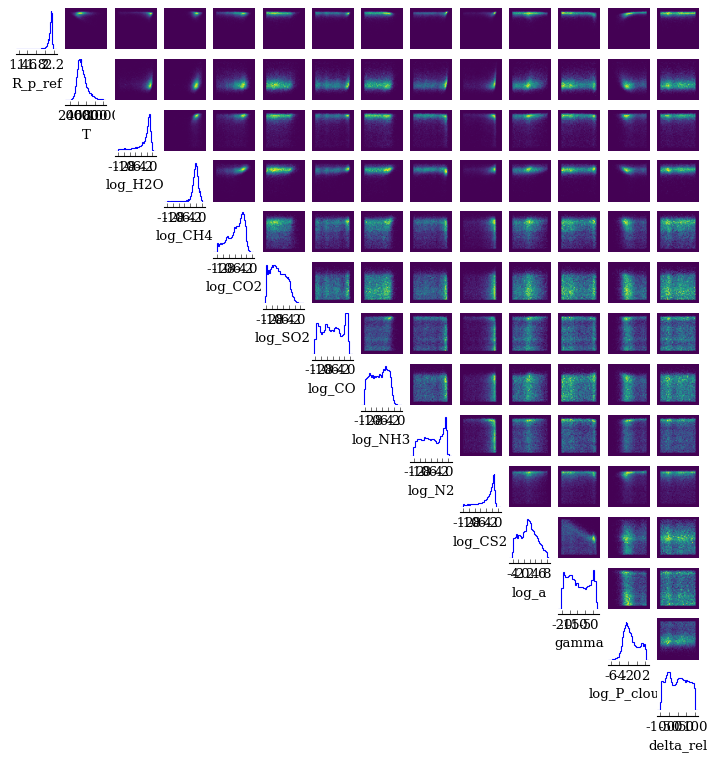

In [ ]:
#***** Optional: regenerate outputs from existing SBI_raw files (no re-training) *****#

# Use this if SBI rounds have already finished and raw files exist in:
# ./POSEIDON_output/<planet_name>/retrievals/SBI_raw/<model_name>_samples.npy

pairplot_from_saved_samples = False

if (retrieval_algorithm.lower() in ['sbi', 'npe', 'snpe', 'npe_c', 'snpe_c', 'npe_a', 'snpe_a', 'fmpe', 'npse', 'nle', 'snle', 'nle_a', 'snle_a', 'nre', 'snre', 'nre_a', 'snre_a', 'nre_b', 'snre_b', 'nre_c', 'snre_c', 'bnre']) and (do_sbi_postprocess_only == True):

    # Pre-interpolate opacities if not already in memory
    try:
        opac
    except NameError:
        opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

    postprocess_sbi_raw(planet, star, model, opac, data, wl, P, priors = priors,
                        P_ref = P_ref, R = R, spectrum_type = 'transmission',
                        N_output_samples = 1000,
                        sbi_round_sizes = sbi_round_sizes)

    # Reload spectrum confidence regions after postprocessing
    wl, spec_low2, spec_low1, spec_median, \
    spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

    spectra_median = []
    spectra_low2 = []
    spectra_low1 = []
    spectra_high1 = []
    spectra_high2 = []

    spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
    spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
    spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
    spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
    spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

    # Generate pairplot directly after postprocessing (optional)
    if pairplot_from_saved_samples:
        sbi_samples_file = (str(OUTPUT_ROOT / planet_name) +
                            '/retrievals/samples/' + model_name + '_samples.txt')
        sbi_samples = np.loadtxt(sbi_samples_file, skiprows = 1)
        fig_pair_post, _ = pairplot(
            sbi_samples,
            labels = list(model['param_names']),
            figsize = (11, 11),
        )
        


## Plotting

### Corner Plot

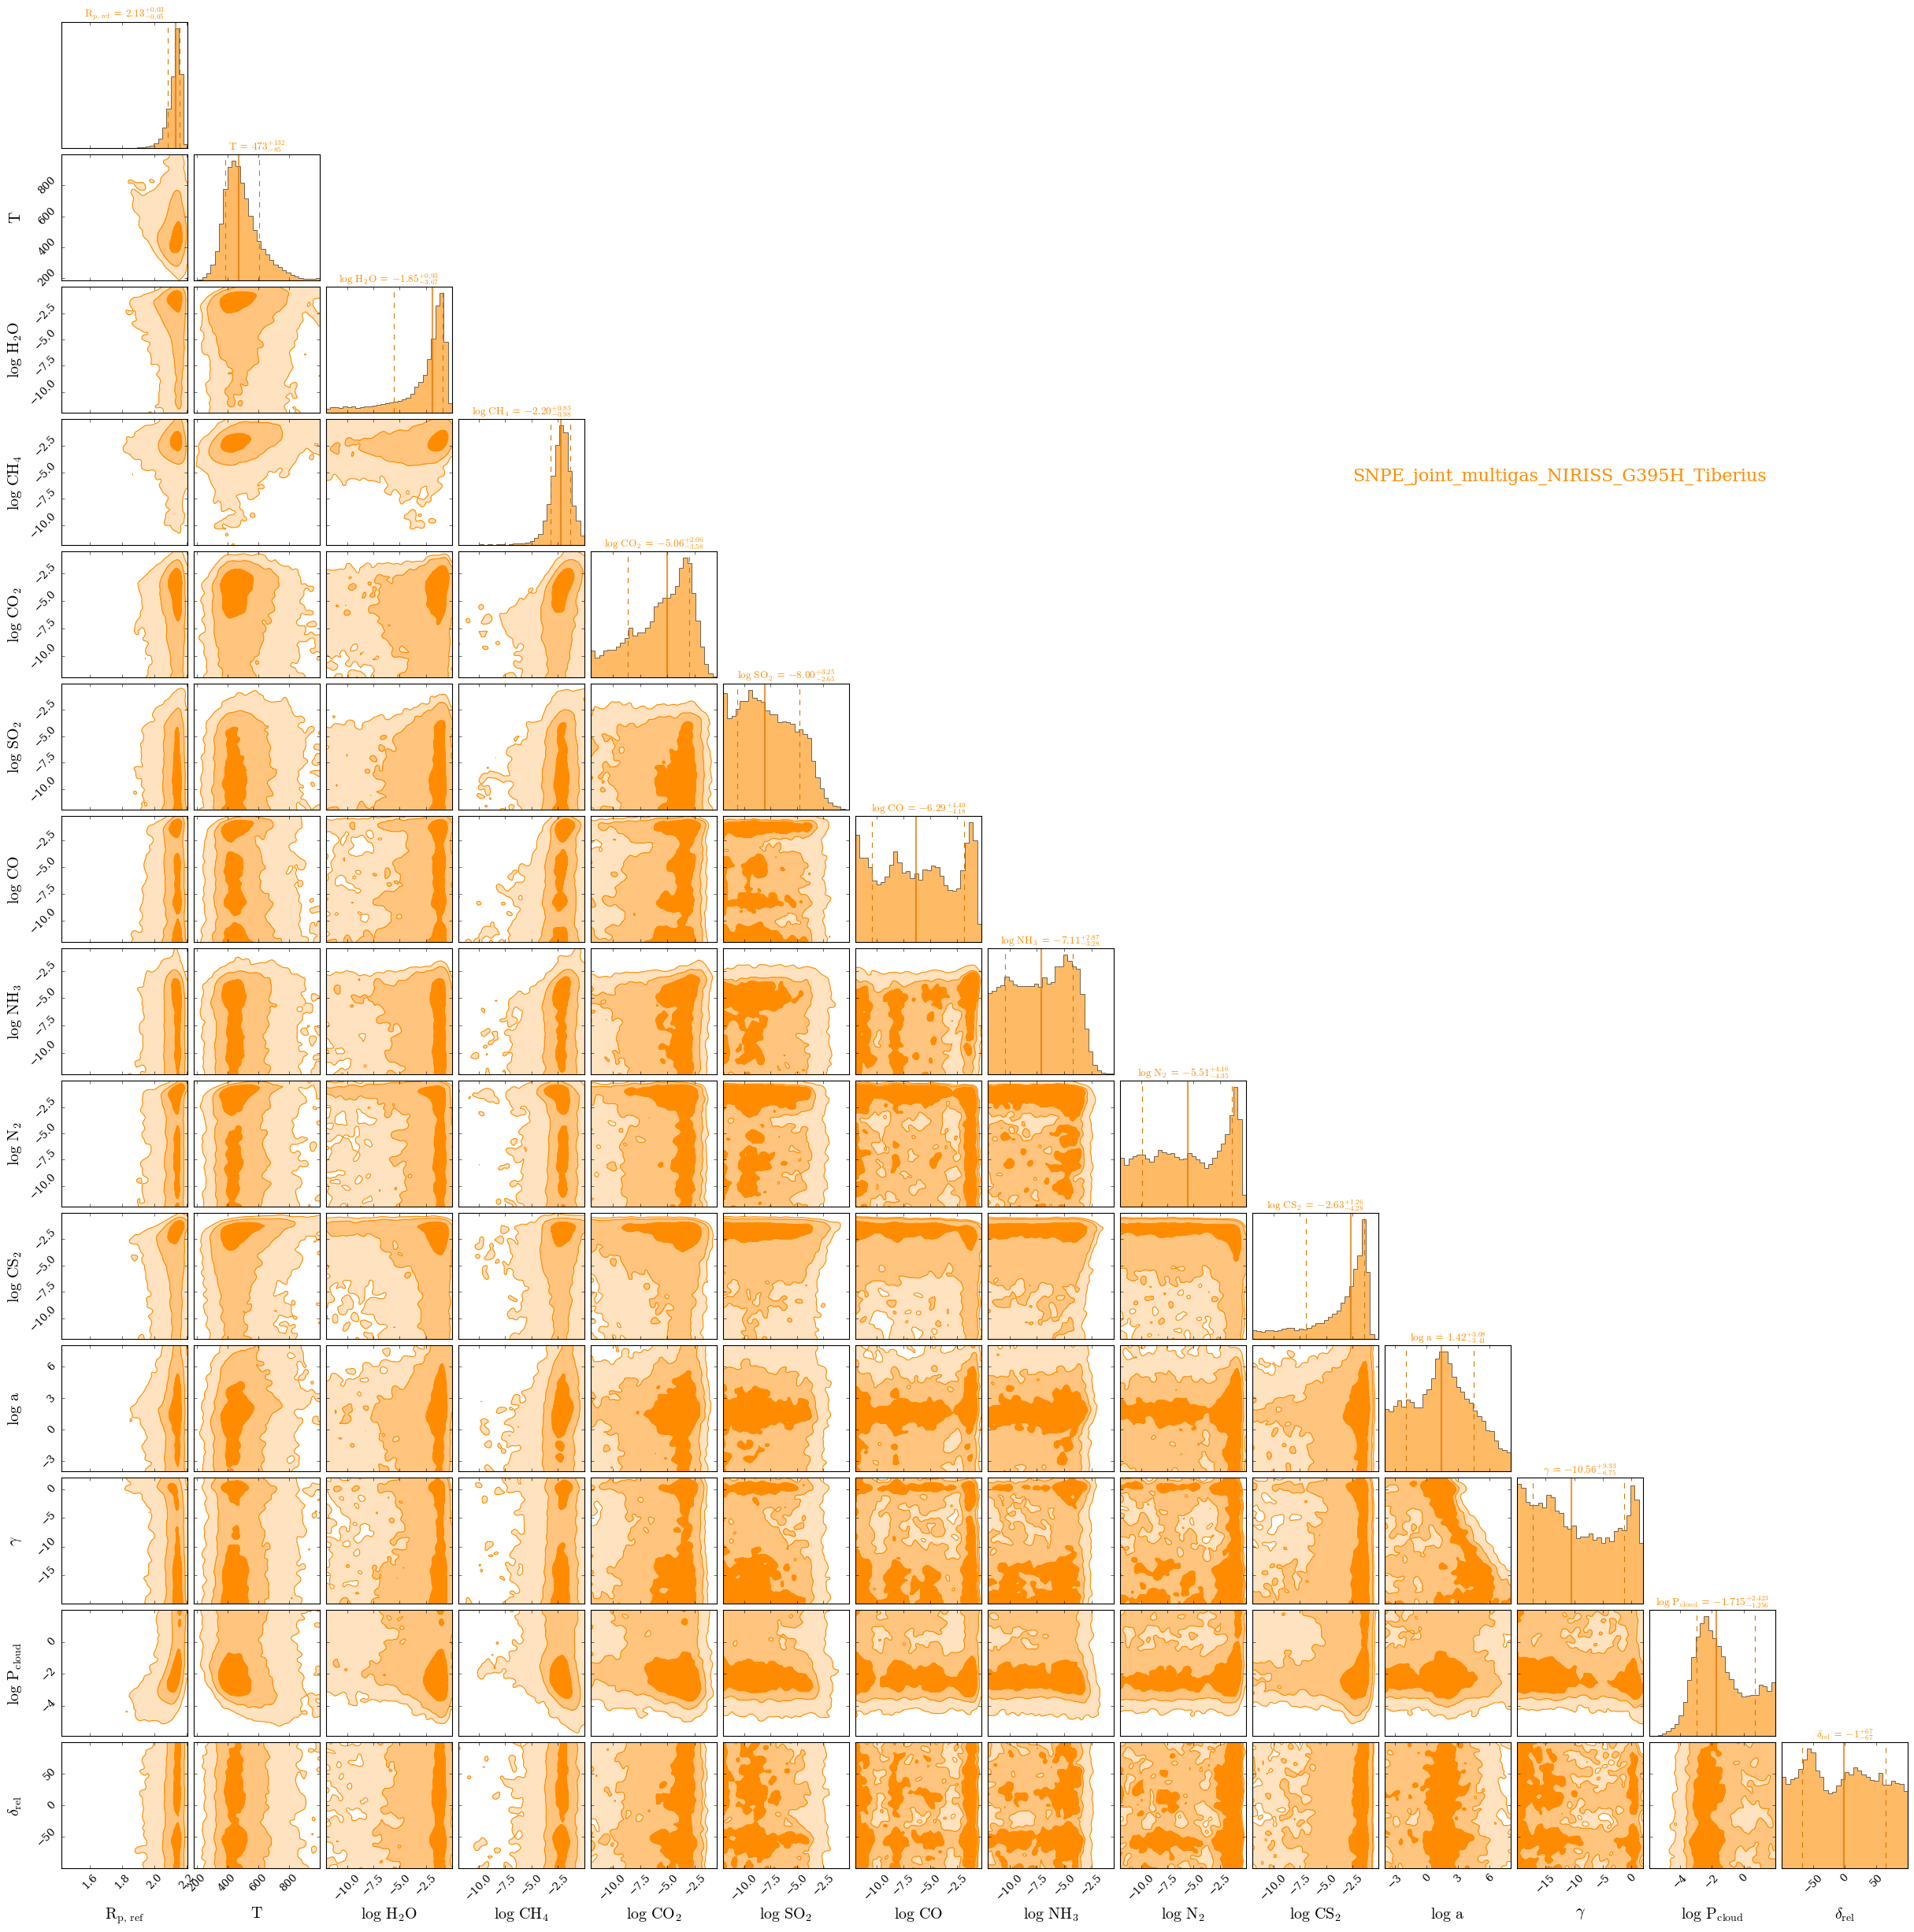

Saved POSEIDON-style corner plot to /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/retrievals/results/SNPE_joint_multigas_NIRISS_G395H_Tiberius_sbi_corner_overplot.pdf


In [ ]:
#***** Make corner / pair plot *****#

from POSEIDON.corner import generate_overplot

posterior_plot_backend = 'poseidon'   # options: 'poseidon' or 'sbi'

sbi_samples_file = str(OUTPUT_ROOT / planet_name / 'retrievals' / 'samples' / (model_name + '_samples.txt'))

if os.path.exists(sbi_samples_file):
    sbi_samples = np.loadtxt(sbi_samples_file, skiprows=1)
    sbi_samples = np.atleast_2d(sbi_samples)
    valid_rows = np.isfinite(sbi_samples).all(axis=1)
    sbi_samples = sbi_samples[valid_rows]

    n_params = min(sbi_samples.shape[1], len(model['param_names']))
    params_to_plot = list(model['param_names'])[:n_params]
    sbi_samples = sbi_samples[:, :n_params]

    if sbi_samples.shape[0] < 2:
        print('Skipping posterior plot: need at least 2 valid posterior samples, found', sbi_samples.shape[0])
    elif sbi_samples.shape[1] < 2:
        print('Skipping posterior plot: need at least 2 parameters to plot, found', sbi_samples.shape[1])
    else:
        if posterior_plot_backend.lower() == 'poseidon':
            generate_overplot(
                planet,
                [model],
                params_to_plot=params_to_plot,
                model_display_names=[model_name],
                colour_schemes=['darkorange'],
                overplot_name=model_name + '_sbi',
                external_samples=[sbi_samples],
                external_param_names=[params_to_plot],
                N_bins=30,
            )
            
            print('Saved POSEIDON-style corner plot to ' +
                  str(OUTPUT_ROOT / planet_name / 'retrievals' / 'results' /
                      ((model_name + '_sbi') + '_corner_overplot.pdf')))
        else:
            fig_pair, _ = pairplot(
                sbi_samples,
                labels=params_to_plot,
                figsize=(11, 11),
            )
            pairplot_file = str(OUTPUT_ROOT / planet_name / 'plots' / (model_name + '_sbi_pairplot.png'))
            plt.savefig(pairplot_file, dpi=200)
            
            print('Saved sbi pairplot to ' + pairplot_file)
else:
    print('No samples file found; skipping posterior plot:', sbi_samples_file)


### Retrieved Spectrum

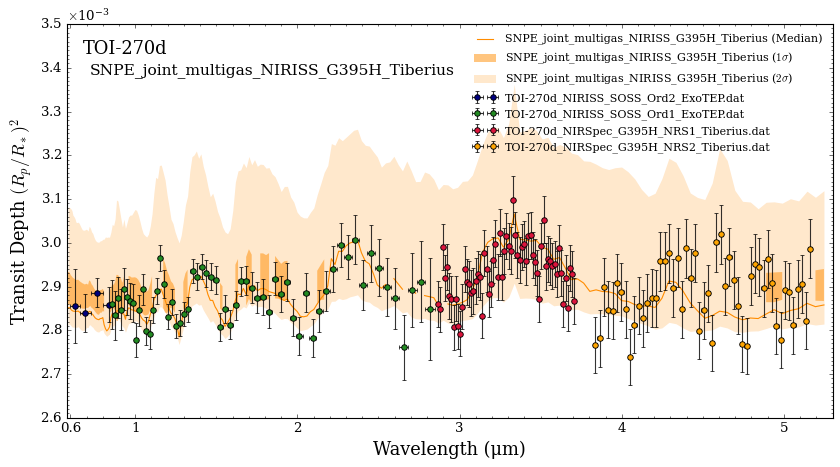

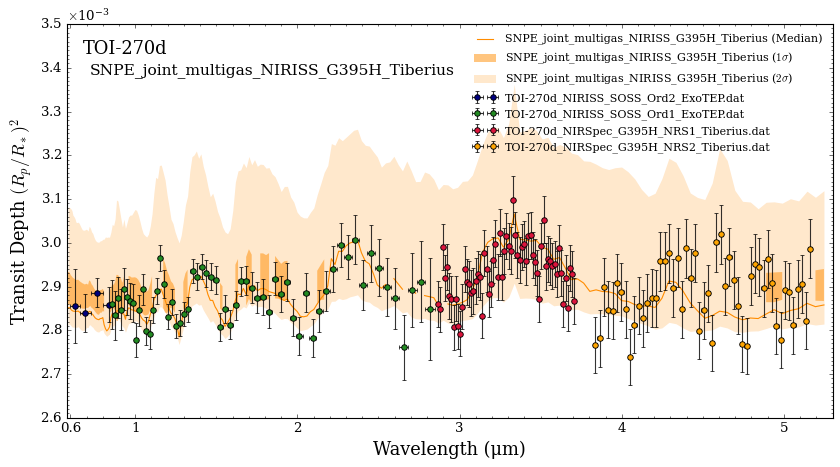

In [8]:
#***** Plot retrieved spectrum (standalone) *****#

from POSEIDON.visuals import plot_spectra_retrieved

wl_ret, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 =     read_retrieved_spectrum(planet_name, model_name)

spectra_median = [(wl_ret, spec_median)]
spectra_low2 = [(wl_ret, spec_low2)]
spectra_low1 = [(wl_ret, spec_low1)]
spectra_high1 = [(wl_ret, spec_high1)]
spectra_high2 = [(wl_ret, spec_high2)]

__data_palette = ['navy', 'forestgreen', 'crimson', 'orange', 'darkblue', 'darkgreen', 'orangered', 'magenta', 'lime', 'cyan', 'gold', 'pink']
n_data_sets = len(data.get('datasets', [])) if isinstance(data, dict) else 0
if n_data_sets <= 0 and isinstance(data, dict) and ('wl_data' in data):
    n_data_sets = len(data['wl_data'])
if n_data_sets <= 0:
    n_data_sets = 1

data_colour_list = [__data_palette[i % len(__data_palette)] for i in range(n_data_sets)]
if isinstance(data, dict) and ('datasets' in data) and (len(data['datasets']) == n_data_sets):
    data_labels = list(data['datasets'])
else:
    data_labels = [f'Dataset {i+1}' for i in range(n_data_sets)]
data_marker_list = ['o'] * n_data_sets
data_marker_size_list = [5] * n_data_sets

wl_min = float(np.min(wl_ret))
wl_max = float(np.max(wl_ret))

_ = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    planet_name,
    data,
    R_to_bin=100,
    show_ymodel=False,
    plt_label=model_name,
    colour_list=['darkorange'],
    binned_colour_list=['darkorange'],
    spectra_labels=[model_name],
    data_colour_list=data_colour_list,
    data_labels=data_labels,
    data_marker_list=data_marker_list,
    data_marker_size_list=data_marker_size_list,
    figure_shape='wide',
    wl_axis='linear',
    wl_min=wl_min,
    wl_max=wl_max,
    legend_location='upper right',
    sigma_to_plot=2,
    # add_retrieved_offsets=True,
    model=model,
)


### Histogram Plot

Saved combined spectrum+histogram plot to /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/plots/SNPE_joint_multigas_NIRISS_G395H_Tiberius_Spectrum_Histogram.pdf


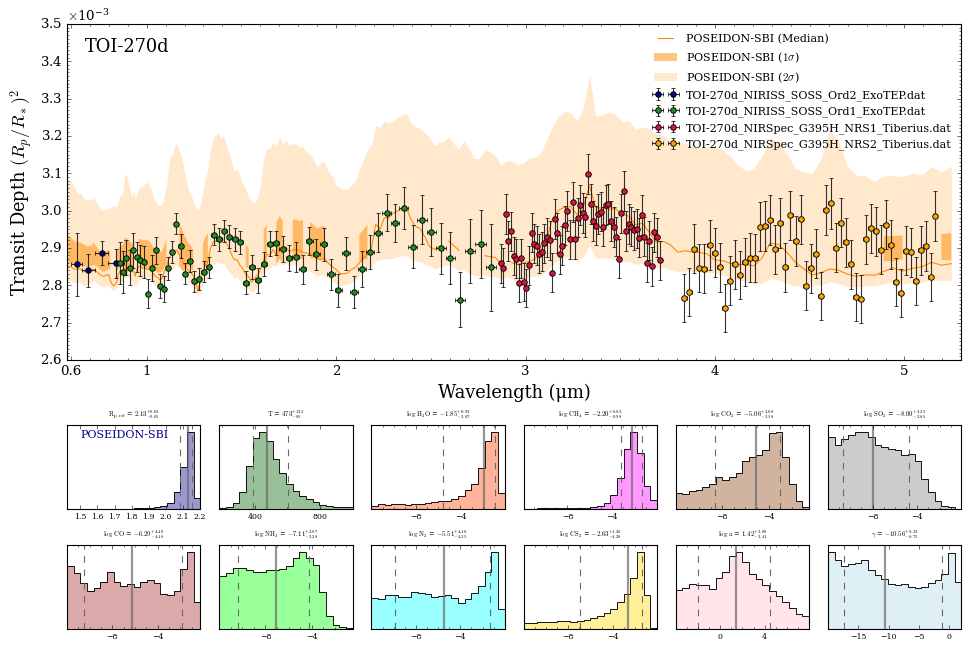

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x800 with 0 Axes>

In [ ]:
#***** Combined spectrum + histogram plot *****#

import matplotlib.pyplot as plt
from POSEIDON.visuals import plot_histograms, plot_spectra_retrieved

sbi_samples_file = str(OUTPUT_ROOT / planet_name / 'retrievals' / 'samples' / (model_name + '_samples.txt'))

if os.path.exists(sbi_samples_file):
    sbi_samples = np.loadtxt(sbi_samples_file, skiprows=1)
    sbi_samples = np.atleast_2d(sbi_samples)
    valid_rows = np.isfinite(sbi_samples).all(axis=1)
    sbi_samples = sbi_samples[valid_rows]

    if sbi_samples.shape[0] < 2:
        print('Skipping histogram panel: need at least 2 valid posterior samples, found', sbi_samples.shape[0])
    else:
        wl_ret, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

        spectra_median = [(wl_ret, spec_median)]
        spectra_low2 = [(wl_ret, spec_low2)]
        spectra_low1 = [(wl_ret, spec_low1)]
        spectra_high1 = [(wl_ret, spec_high1)]
        spectra_high2 = [(wl_ret, spec_high2)]

        __data_palette = ['navy', 'forestgreen', 'crimson', 'orange', 'darkblue', 'darkgreen', 'orangered', 'magenta', 'lime', 'cyan', 'gold', 'pink']
        n_data_sets = len(data.get('datasets', [])) if isinstance(data, dict) else 0
        if n_data_sets <= 0 and isinstance(data, dict) and ('wl_data' in data):
            n_data_sets = len(data['wl_data'])
        if n_data_sets <= 0:
            n_data_sets = 1

        data_colour_list = [__data_palette[i % len(__data_palette)] for i in range(n_data_sets)]
        if isinstance(data, dict) and ('datasets' in data) and (len(data['datasets']) == n_data_sets):
            data_labels = list(data['datasets'])
        else:
            data_labels = [f'Dataset {i+1}' for i in range(n_data_sets)]
        data_marker_list = ['o'] * n_data_sets
        data_marker_size_list = [5] * n_data_sets

        wl_min = float(np.min(wl_ret))
        wl_max = float(np.max(wl_ret))

        n_hist = min(12, sbi_samples.shape[1], len(model['param_names']))
        if n_hist == 0:
            raise Exception('No parameters available to plot.')

        plot_parameters = list(model['param_names'])[:n_hist]
        external_param_names = list(model['param_names'])[:sbi_samples.shape[1]]

        letters = list('abcdefghijkl')[:n_hist]

        row1_letters = letters[:6]
        row2_letters = letters[6:12]
        row1 = ''.join(row1_letters) + '.' * (6 - len(row1_letters))
        row2 = ''.join(row2_letters) + '.' * (6 - len(row2_letters))

        fig_combined = plt.figure(constrained_layout=True, figsize=(12, 8.0))
        axd = fig_combined.subplot_mosaic(
            f"""
            AAAAAA
            AAAAAA
            AAAAAA
            AAAAAA
            {row1}
            {row2}
            """
        )

        ax_spectrum = axd['A']
        axes_histograms = [axd[lbl] for lbl in letters]

        _ = plot_spectra_retrieved(
            spectra_median, spectra_low2, spectra_low1,
            spectra_high1, spectra_high2, planet_name,
            data, R_to_bin=100, show_ymodel=False,
            plt_label=None,
            colour_list=['darkorange'],
            spectra_labels=['POSEIDON-SBI'],
            data_colour_list=data_colour_list,
            data_labels=data_labels,
            data_marker_list=data_marker_list,
            data_marker_size_list=data_marker_size_list,
            figure_shape='wide', wl_axis='linear',
            wl_min=wl_min, wl_max=wl_max,
            legend_location='upper right',
            save_fig=False,
            ax=ax_spectrum,
            # add_retrieved_offsets=True,
            model=model,
        )

        parameter_colour_list = [
            'darkblue', 'darkgreen', 'orangered', 'magenta', 'saddlebrown', 'grey',
            'brown', 'lime', 'cyan', 'gold', 'pink', 'lightblue'
        ][:n_hist]

        _ = plot_histograms(
            planet,
            [model],
            plot_parameters=plot_parameters,
            parameter_colour_list=parameter_colour_list,
            N_bins=[20] * n_hist,
            axes=axes_histograms,
            save_fig=False,
            retrieval_codes=['SBI'],
            retrieval_labels=['POSEIDON-SBI'],
            tick_labelsize = 12, 
            title_fontsize = 12,
            # title_vert_spacing = 0.2,
            external_samples=[sbi_samples],
            external_param_names=[external_param_names],
        )

        out_file = OUTPUT_ROOT / planet_name / 'plots' / (model_name + '_Spectrum_Histogram.pdf')
        fig_combined.savefig(str(out_file), bbox_inches='tight', dpi=400)
        print('Saved combined spectrum+histogram plot to', str(out_file))
else:
    print('No samples file found; skipping histogram panel:', sbi_samples_file)
